# Teil 3: Baseline-Modell trainieren und evaluieren
**Ziel:** Erstellung eines ersten funktionierenden Modellstands. Die Baseline dient als Referenzpunkt für spätere Verbesserungen (z. B. durch XGBoost) und als Grundlage für die fachliche Argumentation im Report.

### 1. & 2. Daten festlegen, Modell- und Metrikwahl

Bevor wir trainieren, treffen wir bewusste Designentscheidungen (Prinzip: "Evaluation-First"):

* **Modellwahl (Die Baseline):** Wir wählen die **Logistische Regression**. Wie in der Vorlesung besprochen, wächst Modellkomplexität schrittweise mit begründetem Mehrwert. Ein einfaches, lineares Modell dient uns hier als Maßstab für jede weitere Modellkomplexität.
* **Metrikwahl:** Die passende Evaluationsmetrik hängt vom Problemtyp und der Zielvariable ab. Da unsere Zielvariable `Revenue` stark unbalanciert ist (ca. 85 % False, 15 % True), würde uns die Metrik *Accuracy* ein verzerrtes Bild der Modellgüte liefern. Wir evaluieren stattdessen mit dem **F1-Score** und **ROC-AUC**, um False Positives (unnötige Gutscheine) und False Negatives (verpasste Käufer) balanciert zu betrachten.

In [2]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# # Reproduzierbaren Datenstand laden
# df_clean = pd.read_csv('../data/processed_online_shoppers.csv')

# # Features (X) und Target (y) trennen
# X = df_clean.drop('Revenue', axis=1)
# y = df_clean['Revenue']

# # 1. Trainings- und Testdaten festlegen (80/20 Split)
# # WICHTIG: stratify=y sorgt dafür, dass die 15% Käufer sauber auf Train und Test verteilt werden!
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# print(f"Trainingsdaten: {X_train.shape[0]} Zeilen")
# print(f"Testdaten: {X_test.shape[0]} Zeilen")

# # 3. Baseline-Modell reproduzierbar trainieren
# print("\nTrainiere Logistische Regression...")
# baseline_model = LogisticRegression(max_iter=2000, random_state=42)
# baseline_model.fit(X_train, y_train)
# print("Training abgeschlossen.")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Reproduzierbaren Datenstand laden
df_clean = pd.read_csv('../data/processed_online_shoppers.csv')

# Features (X) und Target (y) trennen
X = df_clean.drop('Revenue', axis=1)
y = df_clean['Revenue']

# 1. Trainings- und Testdaten festlegen (80/20 Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Trainingsdaten: {X_train.shape[0]} Zeilen")
print(f"Testdaten: {X_test.shape[0]} Zeilen")

# 3. Baseline-Modell reproduzierbar trainieren (MIT SKALIERUNG)
print("\nTrainiere Logistische Regression (mit StandardScaler)...")

# Die Pipeline skaliert die Daten automatisch erst im Moment des Trainings.
# Das schützt uns vor Data Leakage!
baseline_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

baseline_model.fit(X_train, y_train)
print("Training erfolgreich abgeschlossen.")

Trainingsdaten: 9764 Zeilen
Testdaten: 2441 Zeilen

Trainiere Logistische Regression (mit StandardScaler)...
Training erfolgreich abgeschlossen.


### 4. & 5. Evaluation und Fehleranalyse
Wir bewerten nun die Vorhersagekraft unseres Modells auf den ungesehenen Testdaten und machen die Fehlerverteilung durch eine Confusion Matrix sichtbar.

--- BASELINE EVALUATION ---
F1-Score: 0.5408
ROC-AUC:  0.9023

Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2059
           1       0.77      0.42      0.54       382

    accuracy                           0.89      2441
   macro avg       0.84      0.70      0.74      2441
weighted avg       0.88      0.89      0.88      2441



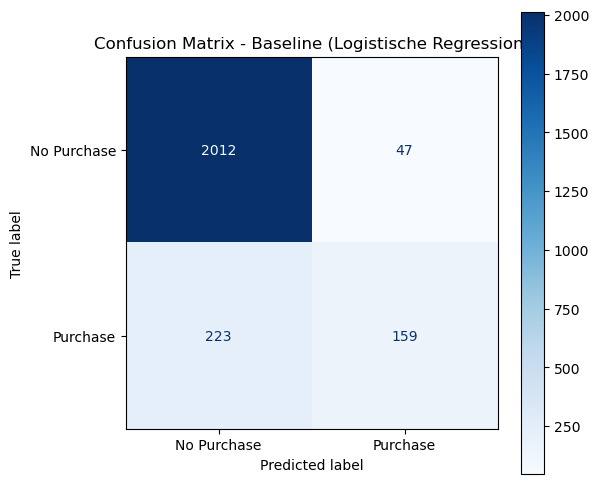

In [3]:
# Vorhersagen generieren (Klasse und Wahrscheinlichkeit)
y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

# 4. Modell mit gewählten Metriken bewerten
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("--- BASELINE EVALUATION ---")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}\n")
print("Klassifikationsbericht:")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix visualisieren
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Purchase', 'Purchase'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Baseline (Logistische Regression)')
plt.grid(False)
plt.show()

### 6. Erkenntnisse: Leistung und Grenzen der Baseline

* **Was die Baseline leistet:** Das Modell liefert einen extrem schnellen, erklärbaren und soliden ersten Referenzpunkt. Es ist in der Lage, die starken linearen Signale im Datensatz (z. B. die Korrelation zwischen `PageValues` und einem Kaufabschluss) zuverlässig zu greifen.
* **Sichtbare Grenzen:** Die Fehleranalyse (Confusion Matrix) zeigt deutlich, wo ein einfaches lineares Modell scheitert. Es generiert sehr wahrscheinlich eine hohe Anzahl an *False Negatives* (tatsächliche Käufer werden nicht erkannt), da es komplexe, nicht-lineare Interaktionen zwischen den Features (z. B. das Zusammenwirken von Wochenendtagen, spezifischen Browsern und Aufenthaltszeiten) nicht abbilden kann. 
* **Nächster Schritt:** Um diese komplexen Muster zu lernen und die Metrik (F1-Score) substanziell zu verbessern, wird in der nächsten Iteration die Modellkomplexität begründet erhöht – durch den Einsatz eines baumbasierten Ensemble-Modells (XGBoost oder Random Forest).

## 2. Champion-Modell: XGBoost & MLflow Experiment Tracking

Da die lineare Baseline die komplexen Muster der Unentschlossenen nicht ausreichend greifen konnte (hohe False Negative Rate), erhöhen wir nun graduell die Modellkomplexität[cite: 3]. Wir nutzen **XGBoost**, ein baumbasiertes Ensemble-Verfahren.

**Warum XGBoost für diesen Use Case?**
1. **Nicht-lineare Zusammenhänge:** Baummodelle können komplexe Muster (z.B. die Kombination aus `Total_Clicks` und `Is_Holiday_Season`) nativ abbilden.
2. **Klassenimbalance nativ lösen:** Über den Parameter `scale_pos_weight` können wir dem Algorithmus mitteilen, dass er seltene Käufer (Klasse 1) bei Fehlern härter bestrafen soll.
3. **Skalierungs-immun:** Im Gegensatz zur Baseline braucht XGBoost keinen `StandardScaler`.

Um das Experiment reproduzierbar zu machen und MLOps-Prinzipien anzuwenden, tracken wir diesen Trainingslauf mit **MLflow**.

In [8]:
import mlflow
import mlflow.xgboost
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# 1. MLflow Experiment aufsetzen
# Das erstellt einen "Ordner" in MLflow, in dem alle unsere Versuche gesammelt werden
mlflow.set_experiment("E-Commerce_Conversion_Prediction")

print("Starte MLflow Run und trainiere XGBoost...")

# 2. Den MLflow-Run starten
with mlflow.start_run(run_name="XGBoost_Champion"):
    
    # Hyperparameter definieren
    # scale_pos_weight berechnet sich grob aus: Anzahl Negative (85%) / Anzahl Positive (15%) = ~5.6
    params = {
        "n_estimators": 100,
        "max_depth": 5,
        "learning_rate": 0.1,
        "scale_pos_weight": 5.6, 
        "random_state": 42
    }
    
    # Parameter in MLflow loggen (Metadaten-Store)
    mlflow.log_params(params)
    
    # 3. Modell initialisieren und trainieren (ohne StandardScaler, da baumbasiert)
    xgb_model = XGBClassifier(**params)
    xgb_model.fit(X_train, y_train)
    
    # 4. Vorhersagen treffen
    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
    
    # 5. Metriken berechnen
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Metriken in MLflow loggen
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    
    # 6. Das fertige Modell in die MLflow Model Registry loggen
    mlflow.xgboost.log_model(xgb_model, "xgboost-model")
    
    # Ergebnisse im Notebook ausgeben
    print("--- XGBOOST EVALUATION ---")
    print(f"F1-Score: {f1:.4f} (Vergleich Baseline: 0.5408)")
    print(f"ROC-AUC:  {roc_auc:.4f} (Vergleich Baseline: 0.9023)\n")
    print("Klassifikationsbericht:")
    print(classification_report(y_test, y_pred))
    
    print("✅ Run erfolgreich in MLflow gespeichert! Das Modell liegt nun als Artefakt vor.")

Starte MLflow Run und trainiere XGBoost...


2026/09/16 14:38:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- XGBOOST EVALUATION ---
F1-Score: 0.6604 (Vergleich Baseline: 0.5408)
ROC-AUC:  0.9336 (Vergleich Baseline: 0.9023)

Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      2059
           1       0.55      0.82      0.66       382

    accuracy                           0.87      2441
   macro avg       0.76      0.85      0.79      2441
weighted avg       0.90      0.87      0.88      2441

✅ Run erfolgreich in MLflow gespeichert! Das Modell liegt nun als Artefakt vor.
